In [12]:
%matplotlib inline
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import butter, filtfilt
from scipy import stats

# calibrate temperature offsets

       now[ms]  AHT_tmp[C]  AHT_hum  BMP_temp[C]  BMP_pres     gx     gy  \
1000     79369       15.68    25.38        16.68    102642  1.389  1.573   
1001     79443       15.67    25.35        16.66    102641  1.748  1.641   
1002     79524       15.64    25.35        16.62    102641  1.748  1.473   
1003     79598       15.63    25.30        16.62    102641  1.885  1.802   
1004     79672       15.60    25.29        16.58    102640  1.763  1.634   
...        ...         ...      ...          ...       ...    ...    ...   
22995  1847392      -17.69    63.85       -16.96    102718  2.298  2.656   
22996  1847474      -17.69    63.84       -16.97    102718  2.588  2.450   
22997  1847556      -17.69    63.83       -16.97    102718  2.313  2.420   
22998  1847638      -17.68    63.85       -16.96    102720  2.557  2.427   
22999  1847725      -17.69    63.81       -16.96    102721  2.588  2.519   

          gz     ax     ay     az  gtemp    magx    magy   magz    volt  
1000  -0.344 

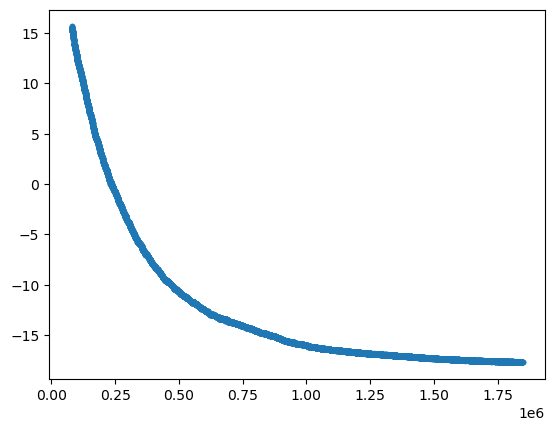

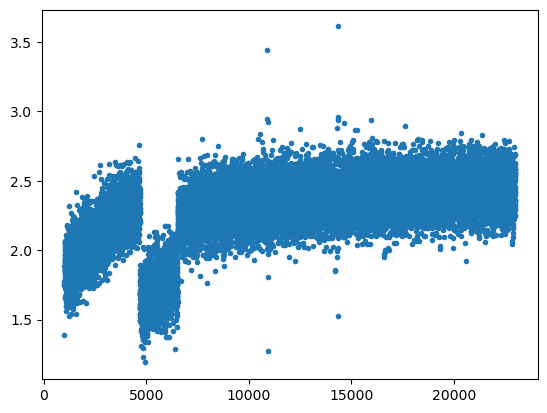

In [16]:
temp_calibration_data=pd.read_csv('temp-calibration.csv')[1000:23000]
print(temp_calibration_data)

plt.plot(temp_calibration_data['now[ms]'],temp_calibration_data['AHT_tmp[C]'],'.')
plt.show()
plt.plot(temp_calibration_data['gx'],'.')
plt.show()

In [14]:
sensors={"gyro":['gx','gy','gz'],"acc":['ax','ay','az'],"mag":['magx','magy','magz']}
offsets={}

## calibrate termometer of gyroscope with calibrated termometer

{'gtemp': {'offset': np.float64(19.48352647581833), 'slope': np.float64(0.8899545931264473)}}


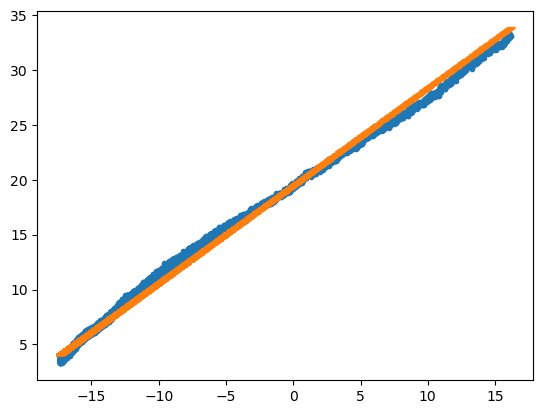

In [29]:
temp_calibration_data['t']=(temp_calibration_data['AHT_tmp[C]']+temp_calibration_data['BMP_temp[C]'])/2
linear=stats.linregress(temp_calibration_data['t'],temp_calibration_data['gtemp'])

offsets['gtemp']={'offset':linear.intercept,'slope':linear.slope}
print(offsets)
temp_calibration_data['gtemp_calibrated']=temp_calibration_data['gtemp']*offsets['gtemp']['slope']-offsets['gtemp']['offset']
plt.plot(temp_calibration_data['t'],temp_calibration_data['gtemp'],'.')
plt.plot(temp_calibration_data['t'],temp_calibration_data['t']*offsets['gtemp']['slope']+offsets['gtemp']['offset'],'_')
plt.show()

## Finding temperature offsets

needed functions

In [30]:
def derivate(x, y, step=1):
    x = np.array(x)
    y = np.array(y)
    dy = y[step:] - y[:-step]
    dx = x[step:] - x[:-step]
    deriv = dy / dx
    return np.concatenate([np.full(step, np.nan), deriv])

def integrate(x, y, step=1):
    x_orig = np.array(x)
    y_orig = np.array(y)
    mask = ~np.isnan(x_orig) & ~np.isnan(y_orig)
    x_c = x_orig[mask]
    y_c = y_orig[mask]

    if len(x_c) <= step:
        return np.full_like(x_orig, np.nan)

    dx = x_c[step:] - x_c[:-step]
    y_ave = (y_c[step:] + y_c[:-step]) / 2.0
    step_areas = y_ave * dx
    
    valid_integral = np.zeros_like(x_c)
    valid_integral[step:] = np.cumsum(step_areas) / step 
    
    full_results = np.full_like(x_orig, np.nan, dtype=float)
    full_results[mask] = valid_integral
    return full_results
def lowpass_filter(data, cutoff, fs, order=2):
    # fs = sampling frequency, cutoff = frequency to block
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data.fillna(method='ffill').fillna(method='bfill'))

denoise

In [31]:
for sensor in sensors:
    sns = sensors[sensor]
    for i in range(len(sns)):
        col = sns[i]
        
        # 1. Kill high-frequency noise but keep the "smooth jumps"
        raw_series = temp_calibration_data[col]
        # fs=1 (assuming 1 sample per unit), cutoff=0.01 (adjust to keep jumps)
        temp_calibration_data[col+'_denoised'] = lowpass_filter(raw_series, cutoff=0.01, fs=1)


/tmp/ipykernel_8928/2450369995.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return filtfilt(b, a, data.fillna(method='ffill').fillna(method='bfill'))


smoothing the 'jumps' in data and finding temperature offsets

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


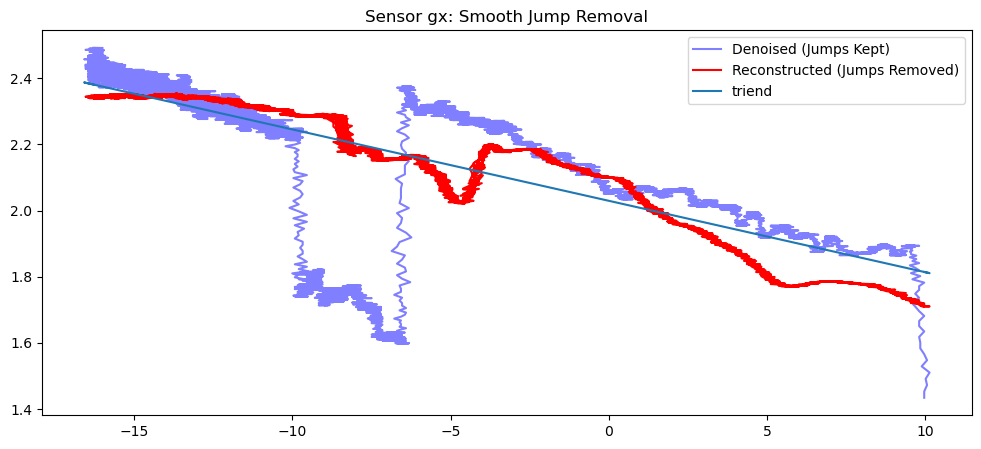

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


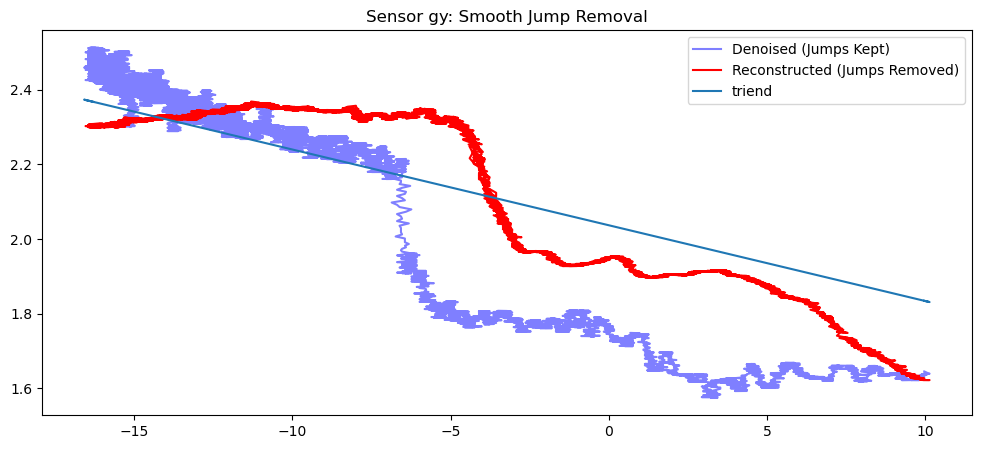

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


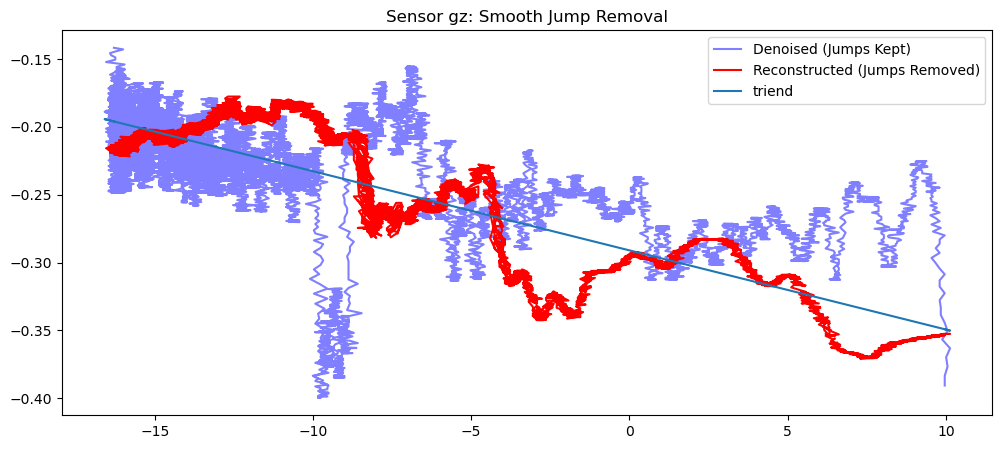

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


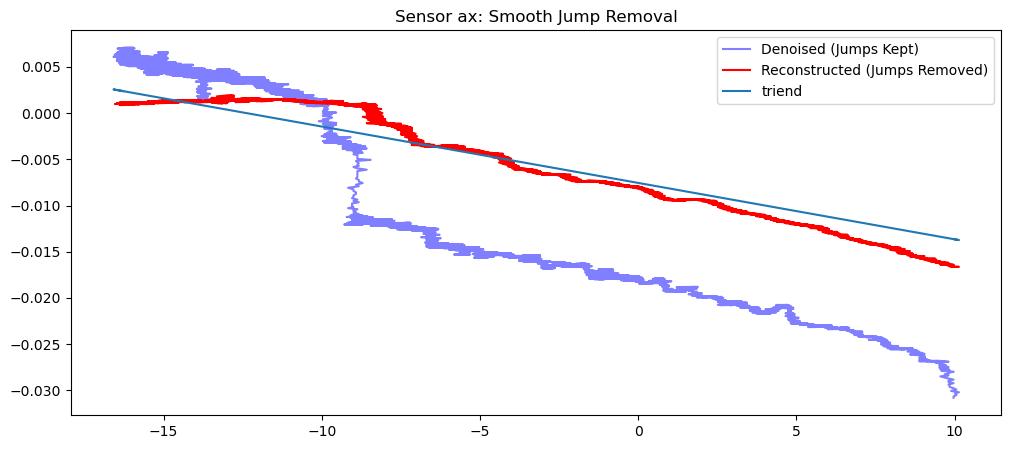

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


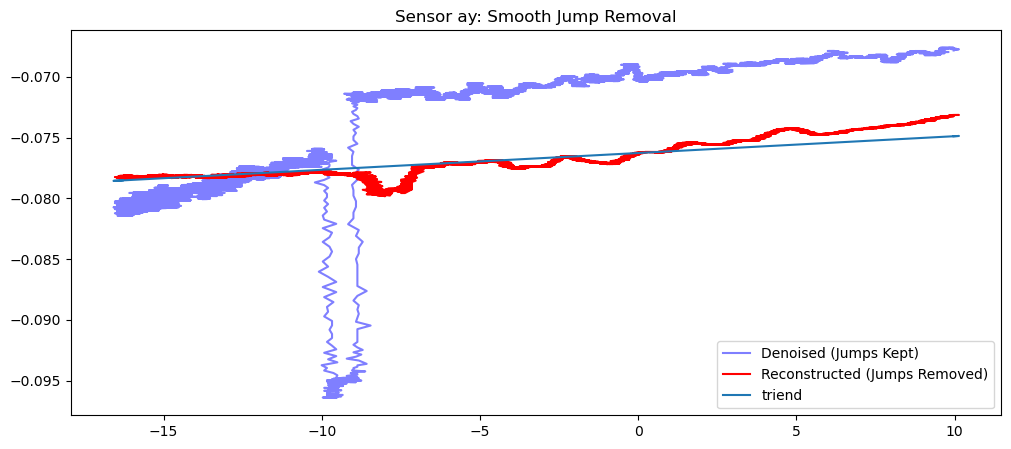

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


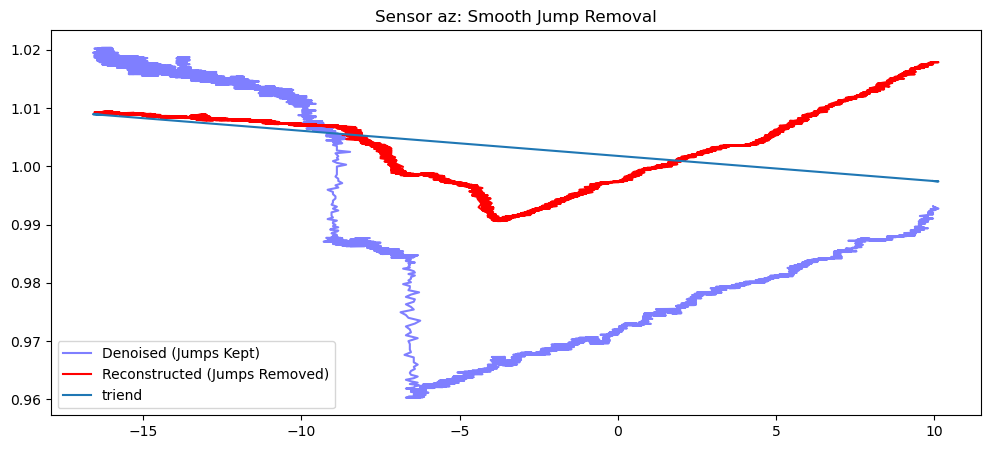

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


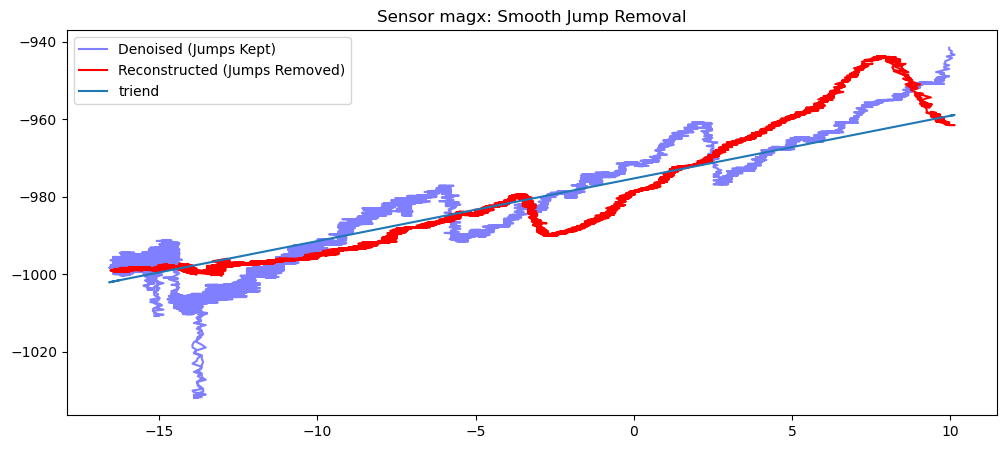

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


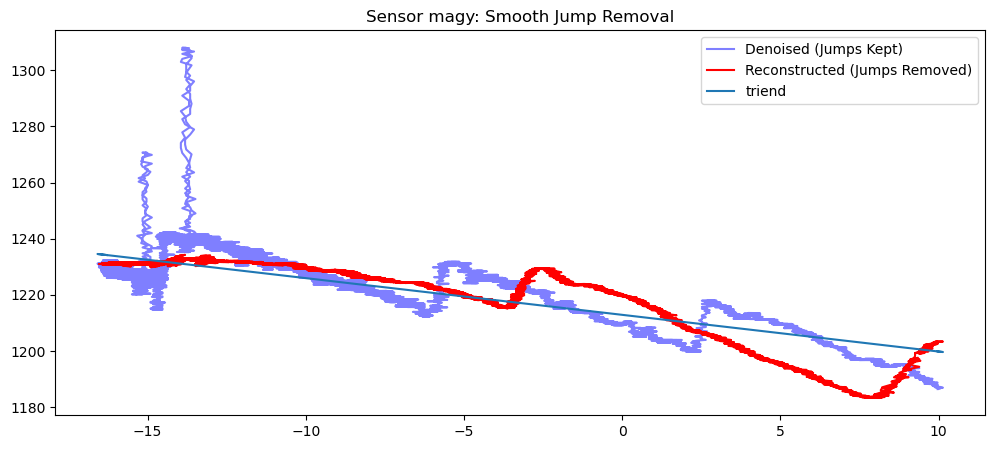

/tmp/ipykernel_8928/2450369995.py:6: RuntimeWarning: divide by zero encountered in divide
  deriv = dy / dx


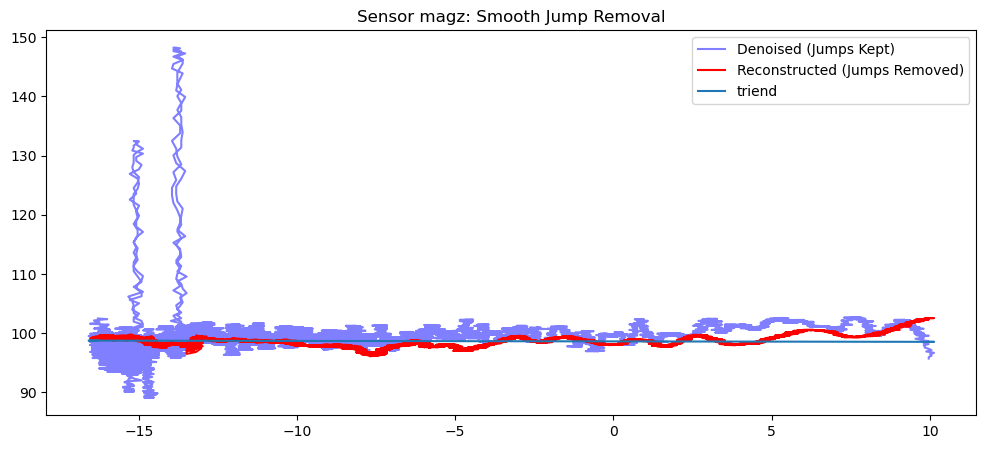

In [32]:


for sensor in sensors:
    sns = sensors[sensor]
    for i in range(len(sns)):
        col = sns[i]

        # 2. Derivative on the denoised signal
        # Use a medium step to capture the "smooth" jump slope
        deriv = derivate(temp_calibration_data['gtemp_calibrated'], 
                         temp_calibration_data[col+'_denoised'], 100)
        
        # 3. Target the "Smooth Jumps"
        # Since jumps are smoother than noise, we use a window that matches jump width
        deriv_series = pd.Series(deriv)
        rolling_median = deriv_series.rolling(window=500, center=True).median()
        
        # Thresholding the derivative itself: 
        # If the rate of change is higher than 10x the median drift, it's a jump
        drift_level = np.nanmedian(np.abs(deriv))
        jump_mask = np.abs(deriv) > (drift_level * 5) 
        
        deriv_cleaned = deriv.copy()
        deriv_cleaned[jump_mask] = np.nan # Clip the smooth jumps
        
        # 4. Fill gaps and smooth for final trend
        temp_calibration_data[col+'_derivative'] = (
            pd.Series(deriv_cleaned)
            .interpolate(method='linear')
            .rolling(window=200, center=True).mean()
        )

        # 5. Reconstruct
        recon_delta = integrate(temp_calibration_data['gtemp_calibrated'], 
                                temp_calibration_data[col+'_derivative'], 5)
        
        
        # Snap reconstruction to data
        
        mask = ~np.isnan(recon_delta) & ~np.isnan(temp_calibration_data[col+'_denoised'])
        bias = np.mean(temp_calibration_data[col+'_denoised'][mask] - recon_delta[mask])
        temp_calibration_data[col+'_reconstructed'] = recon_delta + bias

        regr=stats.linregress(temp_calibration_data['gtemp_calibrated'][mask], temp_calibration_data[col+'_reconstructed'][mask])

        offsets[col]={'t':regr.slope}
        # 6. Plotting
        plt.figure(figsize=(12, 5))
        plt.plot(temp_calibration_data['gtemp_calibrated'], temp_calibration_data[col+'_denoised'], 'b', label='Denoised (Jumps Kept)', alpha=0.5)
        plt.plot(temp_calibration_data['gtemp_calibrated'], temp_calibration_data[col+'_reconstructed'], 'r', label='Reconstructed (Jumps Removed)')
        plt.plot(temp_calibration_data['gtemp_calibrated'], temp_calibration_data['gtemp_calibrated']*offsets[col]['t']+regr.intercept, '-', label='triend')
        plt.legend()
        plt.title(f"Sensor {col}: Smooth Jump Removal")
        plt.show()

downloading results

In [35]:
print(offsets)
with open('calibration_offsets.json', 'w') as f:
    f.write(str(offsets))

{'gtemp': {'offset': np.float64(19.48352647581833), 'slope': np.float64(0.8899545931264473)}, 'gx': {'t': np.float64(-0.021586792358359138)}, 'gy': {'t': np.float64(-0.020303052338820144)}, 'gz': {'t': np.float64(-0.005832454539831817)}, 'ax': {'t': np.float64(-0.0006102163154276929)}, 'ay': {'t': np.float64(0.00013838381249620173)}, 'az': {'t': np.float64(-0.00043185604998110703)}, 'magx': {'t': np.float64(1.616134483443776)}, 'magy': {'t': np.float64(-1.3068505098634506)}, 'magz': {'t': np.float64(-0.007807677473116862)}}


# find the absolute offsets at 0C


collect and plot data in real time

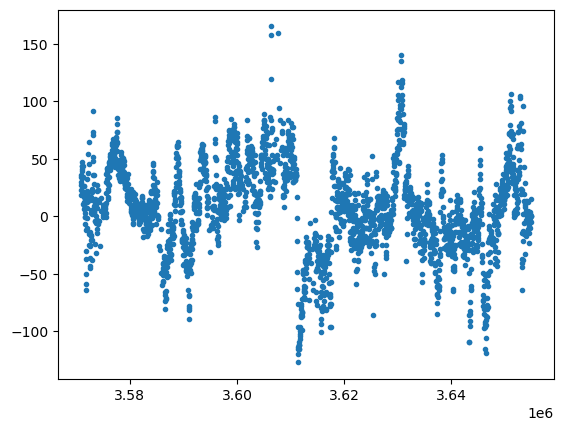

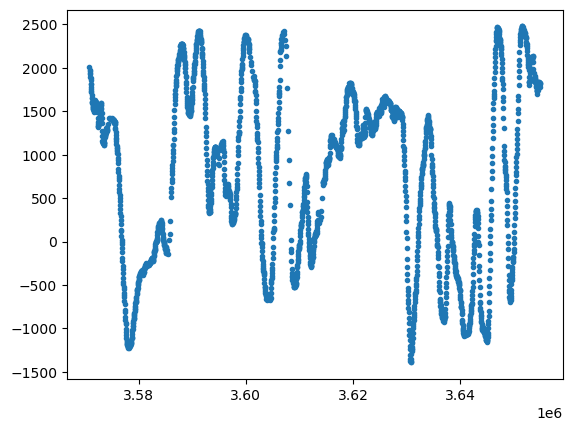

In [33]:
final_calibration_data=pd.read_csv('final-calibration.csv')

plt.plot(final_calibration_data['now[ms]'],final_calibration_data['gx'],'.')
plt.show()
plt.plot(final_calibration_data['now[ms]'],final_calibration_data['magx'],'.')
plt.show()

In [10]:
print(offsets)
final_calibration_data['gtemp_calibrated']=final_calibration_data['gtemp']*offsets['gtemp']['slope']-offsets['gtemp']['offset']
for sensor in sensors:
    sns=sensors[sensor]
    for i in range(len(sns)):
        final_calibration_data[sns[i]+'_calibrated']=final_calibration_data[sns[i]]+final_calibration_data['gtemp_calibrated']*offsets[sns[i]]['t']
        final_calibration_data[sns[i]+'_smoothed']=final_calibration_data[sns[i]+'_calibrated'].rolling(window=1).mean()

{'gtemp': {'offset': np.float64(19.48352647581833), 'slope': np.float64(0.8899545931264473)}, 'gx': {'t': np.float64(-0.021586792358359138)}, 'gy': {'t': np.float64(-0.020303052338820144)}, 'gz': {'t': np.float64(-0.005832454539831817)}, 'ax': {'t': np.float64(-0.0006102163154276929)}, 'ay': {'t': np.float64(0.00013838381249620173)}, 'az': {'t': np.float64(-0.00043185604998110703)}, 'magx': {'t': np.float64(1.616134483443776)}, 'magy': {'t': np.float64(-1.3068505098634506)}, 'magz': {'t': np.float64(-0.007807677473116862)}}


gyro


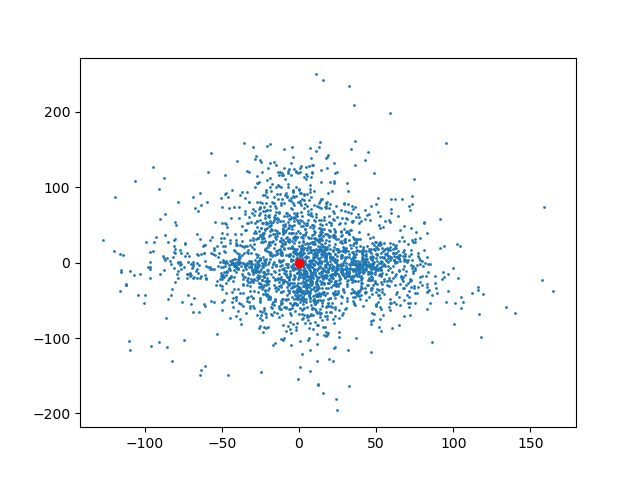

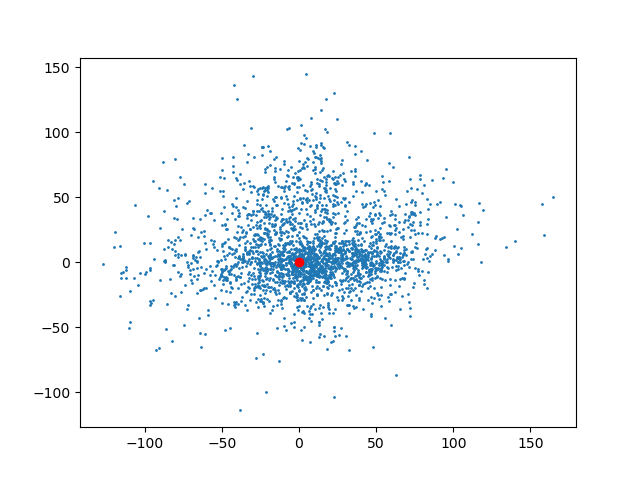

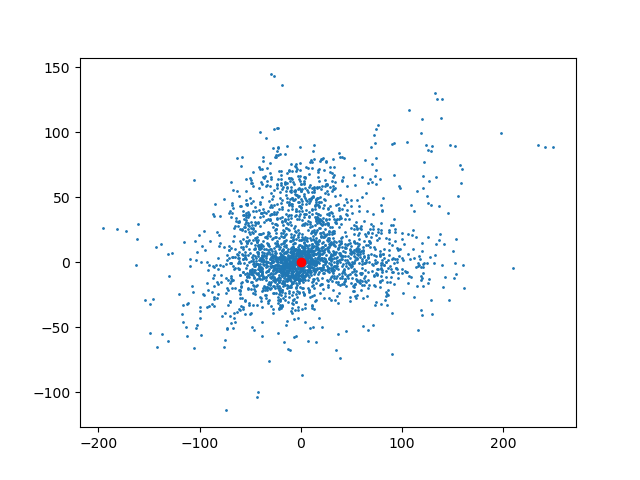

acc


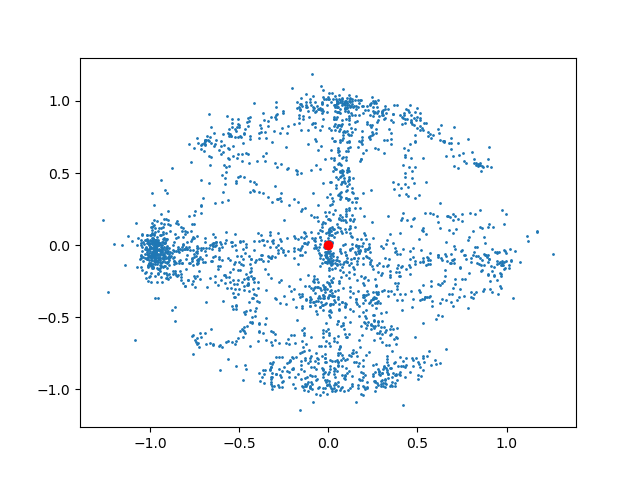

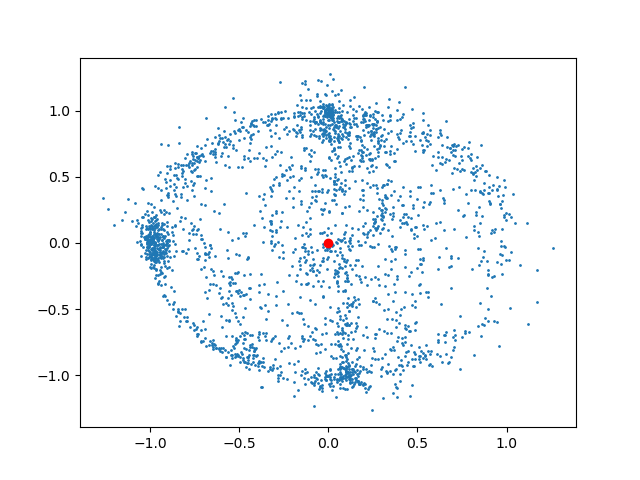

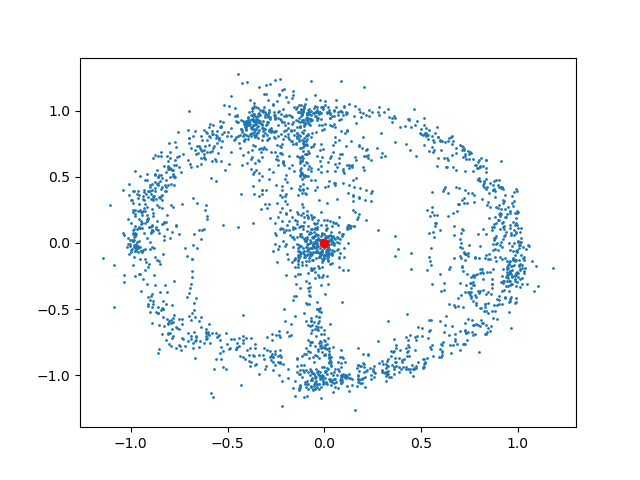

mag


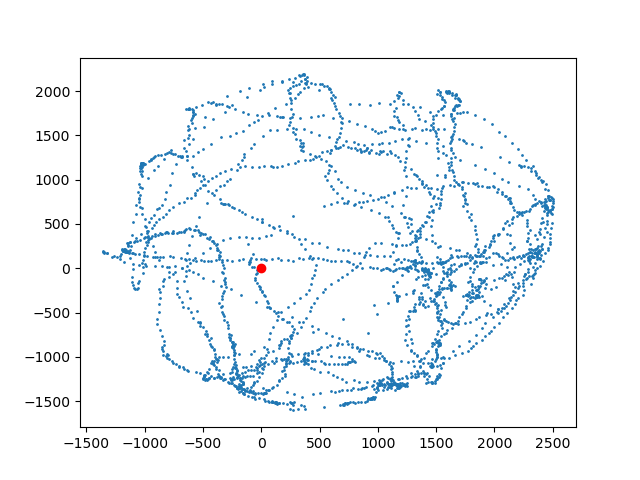

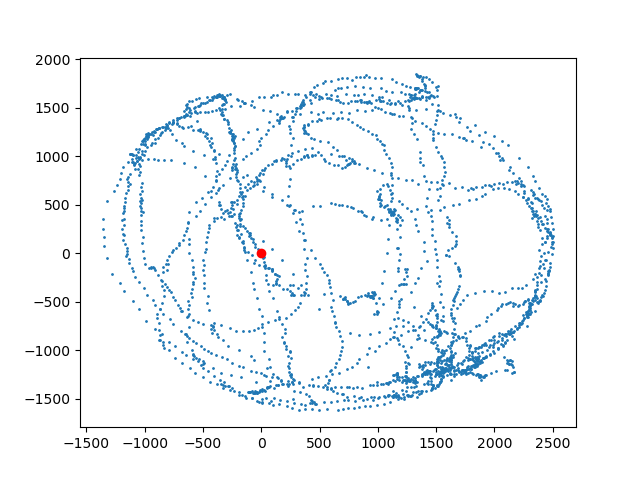

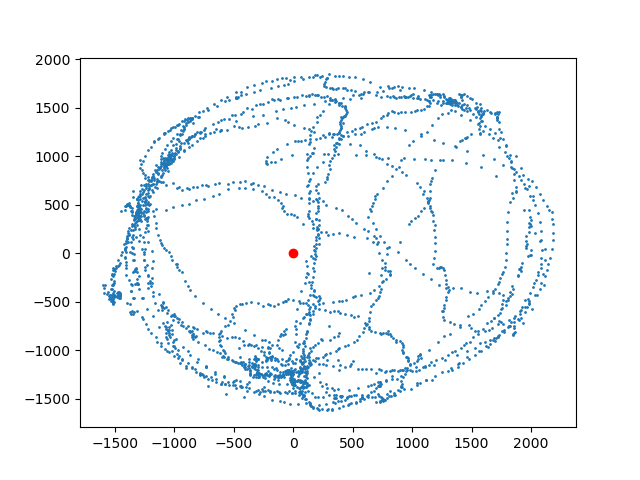

In [11]:

for sensor in sensors:
    print(sensor)
    sns=sensors[sensor]
    for i in range(len(sns)):
        for j in range(i+1,len(sns)):
            plt.scatter(final_calibration_data[sns[i]+'_smoothed'],final_calibration_data[sns[j]+'_smoothed'],s=1)
            plt.plot(0,0,'o',color='red')
            plt.show()

